In [9]:
import h5py
import numpy as np

In [25]:
with h5py.File(r"E:\Dai hoc\2526I\dacn\flow-matching\data\traintest_hcd.hdf5") as f:
    print(f.keys())
    seqs = f["sequence_integer"][:8]
    intensities = f["intensities_raw"][:8]
    charge_oh = f["precursor_charge_onehot"][:8]
    masses_pred = f["masses_pred"][:8]
    masses_raw = f["masses_raw"][:8]

<KeysViewHDF5 ['collision_energy', 'collision_energy_aligned', 'collision_energy_aligned_normed', 'intensities_raw', 'masses_pred', 'masses_raw', 'method', 'precursor_charge_onehot', 'rawfile', 'reverse', 'scan_number', 'score', 'sequence_integer', 'sequence_onehot']>


In [10]:
charges = np.argmax(charge_oh, axis=1) + 1

In [11]:
charges

array([3, 2, 2, 2, 2, 2, 3, 3])

In [14]:
from utils import get_peptide_seq

In [16]:
get_peptide_seq(seqs[0])

'WEVYPVNSTFRVLVSGATR'

In [51]:
np.zeros(2 * 10 * 10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [79]:
from pyteomics import mass

def calculate_fragments(peptide_sequence, charge=2, max_len: int= 30, max_frag_charge: int = 3):
    # print(f"Peptide: {peptide_sequence} | Max Charge: {charge}")
    # print(f"{'Ion':<10} | {'m/z':<10}")
    # print("-" * 25)
    L =len(peptide_sequence)
    # Tính toán các loại ion b và y
    # b_series: từ đầu N-terminus
    # y_series: từ đầu C-
    intensity = np.zeros(2 * (max_len - 1) * max_frag_charge)
    for i in range(1, L):
        for z in range(1, min(max_frag_charge + 1, charge + 1)):
            # Tính ion b
            b_mz = mass.fast_mass(peptide_sequence[:i], ion_type='b', charge=z)
            # print(f"b{i}^{z}+    | {b_mz:.4f}")
            intensity[ (i-1) * 6 + max_frag_charge + z - 1] = b_mz
            # Tính ion y
            y_mz = mass.fast_mass(peptide_sequence[i:], ion_type='y', charge=z)
            # print(f"y{L - i}^{z}+    | {y_mz:.4f}")
            intensity[(L - i - 1) * 6 + z - 1] = y_mz
    return intensity


In [67]:
intensities[0].dtype

dtype('float64')

In [73]:
calculate_fragments(get_peptide_seq(seqs[0]), charges[0]).dtype

dtype('float64')

In [80]:
calculate_fragments(get_peptide_seq(seqs[0]), charges[0]) - masses_pred[0]

array([ 7.06998549e-09,  3.41998430e-09,  2.20332197e-09, -5.03700335e-08,
       -2.53000252e-08, -1.69433463e-08, -5.24519976e-07, -2.62374982e-07,
       -1.74993318e-07,  3.75999321e-08,  1.86849718e-08,  1.23799850e-08,
       -7.39810048e-07, -3.70020018e-07, -2.46756684e-07, -4.94101187e-08,
       -2.48200536e-08, -1.66233747e-08, -1.01924002e-06, -5.09735003e-07,
       -3.39899998e-07, -5.16860041e-07, -2.58545015e-07, -1.72439997e-07,
       -6.14970020e-07, -3.07600004e-07, -2.05143323e-07, -6.68010102e-07,
       -3.34120045e-07, -2.22823360e-07, -7.01980071e-07, -3.51105029e-07,
       -2.34146682e-07, -7.55020096e-07, -3.77625042e-07, -2.51826691e-07,
       -7.24850111e-07, -3.62540050e-07, -2.41770039e-07, -3.13880037e-07,
       -1.57055013e-07, -1.04779986e-07, -8.11860104e-07, -4.06045046e-07,
       -2.70773398e-07,  9.03900172e-08,  4.50800144e-08,  2.99767180e-08,
       -7.88260081e-07, -3.94245035e-07, -2.62906667e-07, -4.41200200e-07,
       -2.20715037e-07, -

In [ ]:
np.count(seqs[0])

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18]),)

In [ ]:
mzs

In [ ]:
import matplotlib.pyplot as plt
from spectrum_utils import spectrum
from spectrum_utils.plot import spectrum as plot_spectrum

def plot_intensity_spectrum(seq, charge, intensities):
    precursor_mz = mass.fast_mass(seq, charge=charge)
    mzs = calculate_fragments(seq, charge)
    spec = spectrum.MsmsSpectrum(
        identifier=f"{seq}_{charge}",
        precursor_mz=precursor_mz,
        precursor_charge=charge,
        mz=mzs,
        intensity=intensities
    )
    plot_spectrum(spec)
    plt.show()

In [82]:
sequence = get_peptide_seq(seqs[0])

In [84]:
intensities[0]

array([ 0.03333019,  0.        ,  0.        ,  0.00833965,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.39771285,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.12638215,  0.        ,  0.        ,  0.00881359,  0.        ,
        0.        ,  0.0085394 ,  0.        ,  0.        ,  0.02134586,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.01633287,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.01483933,  0.        ,  0.02334369,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.00457667,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.00765157,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.02404616,  0.        ,  0.  

In [88]:
max(calculate_fragments(sequence, charges[0]))

np.float64(2007.03343814346)

2007.03343814346


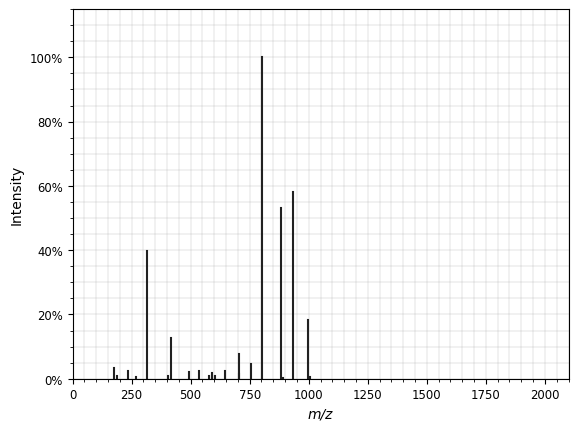

In [92]:
plot_intensity_spectrum(sequence, charges[0], intensities[0])